# Business Thresholds and Decisioning

This turns model probabilities into business decisions.

The goal is to compare different high-risk probability thresholds and design a simple credit decision policy: approve, review, or reject.

## 1. Environment Setup

Load libraries, connect to the project source code, and prepare output folders.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from credit_risk_platform.data.german_credit import interim_german_credit_dir
from credit_risk_platform.utils.io import load_csv

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")

tables_dir = project_root / "artifacts" / "tables"
profiles_dir = project_root / "artifacts" / "profiles"
figures_dir = project_root / "artifacts" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
profiles_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("project_root:", project_root)

project_root: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform


## 2. Load Data and Champion Model

Load the standardized dataset and the saved Random Forest champion pipeline from Notebook 09.

In [2]:
interim_dir = interim_german_credit_dir(project_root)
df = load_csv(interim_dir / "german_credit_standardized.csv")

champion_model_path = project_root / "models" / "random_forest_champion_pipeline.joblib"
champion_pipeline = joblib.load(champion_model_path)

print("Dataset shape:", df.shape)
print("Champion model path:", champion_model_path)
df.head()

Dataset shape: (1000, 24)
Champion model path: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/models/random_forest_champion_pipeline.joblib


,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate_pct_income,personal_status_sex,...,other_installment_plans,housing,existing_credits_count,job_type,liable_people_count,telephone,foreign_worker,risk_class,risk_label,TARGET
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


## 3. Recreate the Validation Set

Use the same split from the modeling notebooks so threshold analysis is performed on validation predictions.

In [3]:
target_col = "TARGET"
identifier_cols = ["applicant_id"]
target_label_cols = ["risk_class", "risk_label"]
exclude_from_features = identifier_cols + target_label_cols + [target_col]

feature_cols = [col for col in df.columns if col not in exclude_from_features]
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Validation rows:", len(X_valid))
print("Validation bad-risk rate:", round(y_valid.mean(), 4))

Validation rows: 150
Validation bad-risk rate: 0.3


## 4. Score Validation Applicants

Generate predicted high-risk probabilities for validation applicants.

In [4]:
valid_scores = pd.DataFrame(
    {
        "actual_high_risk": y_valid,
        "predicted_high_risk_probability": champion_pipeline.predict_proba(X_valid)[:, 1],
    },
    index=X_valid.index,
)

valid_scores.head()

,actual_high_risk,predicted_high_risk_probability
309,0,0.456577
404,0,0.290973
940,0,0.198351
832,1,0.720902
575,0,0.389639


## 5. Compare Classification Thresholds

A threshold controls when an applicant is classified as high risk. Lower thresholds catch more risky applicants but may flag more low-risk applicants incorrectly.

In [5]:
def evaluate_threshold(threshold: float) -> dict:
    y_pred = (valid_scores["predicted_high_risk_probability"] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()

    return {
        "threshold": threshold,
        "approve_or_low_risk_count": int((y_pred == 0).sum()),
        "high_risk_count": int((y_pred == 1).sum()),
        "true_positive_high_risk": int(tp),
        "false_positive_low_risk_flagged": int(fp),
        "false_negative_high_risk_missed": int(fn),
        "true_negative_low_risk": int(tn),
        "precision_high_risk": round(precision_score(y_valid, y_pred, zero_division=0), 4),
        "recall_high_risk": round(recall_score(y_valid, y_pred, zero_division=0), 4),
        "f1_high_risk": round(f1_score(y_valid, y_pred, zero_division=0), 4),
    }

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
threshold_results = pd.DataFrame([evaluate_threshold(threshold) for threshold in thresholds])
threshold_results

,threshold,approve_or_low_risk_count,high_risk_count,true_positive_high_risk,false_positive_low_risk_flagged,false_negative_high_risk_missed,true_negative_low_risk,precision_high_risk,recall_high_risk,f1_high_risk
0,0.30,43,107,43,64,2,41,0.4019,0.9556,0.5658
1,0.35,55,95,41,54,4,51,0.4316,0.9111,0.5857
2,0.40,70,80,37,43,8,62,0.4625,0.8222,0.5920
3,0.45,81,69,33,36,12,69,0.4783,0.7333,0.5789
4,0.50,94,56,29,27,16,78,0.5179,0.6444,0.5743
5,0.55,110,40,24,16,21,89,0.6000,0.5333,0.5647
6,0.60,124,26,18,8,27,97,0.6923,0.4000,0.5070
7,0.65,132,18,12,6,33,99,0.6667,0.2667,0.3810
8,0.70,139,11,7,4,38,101,0.6364,0.1556,0.2500


## 6. Visualize Threshold Tradeoffs

Review how precision, recall, and missed high-risk applicants change as the threshold changes.

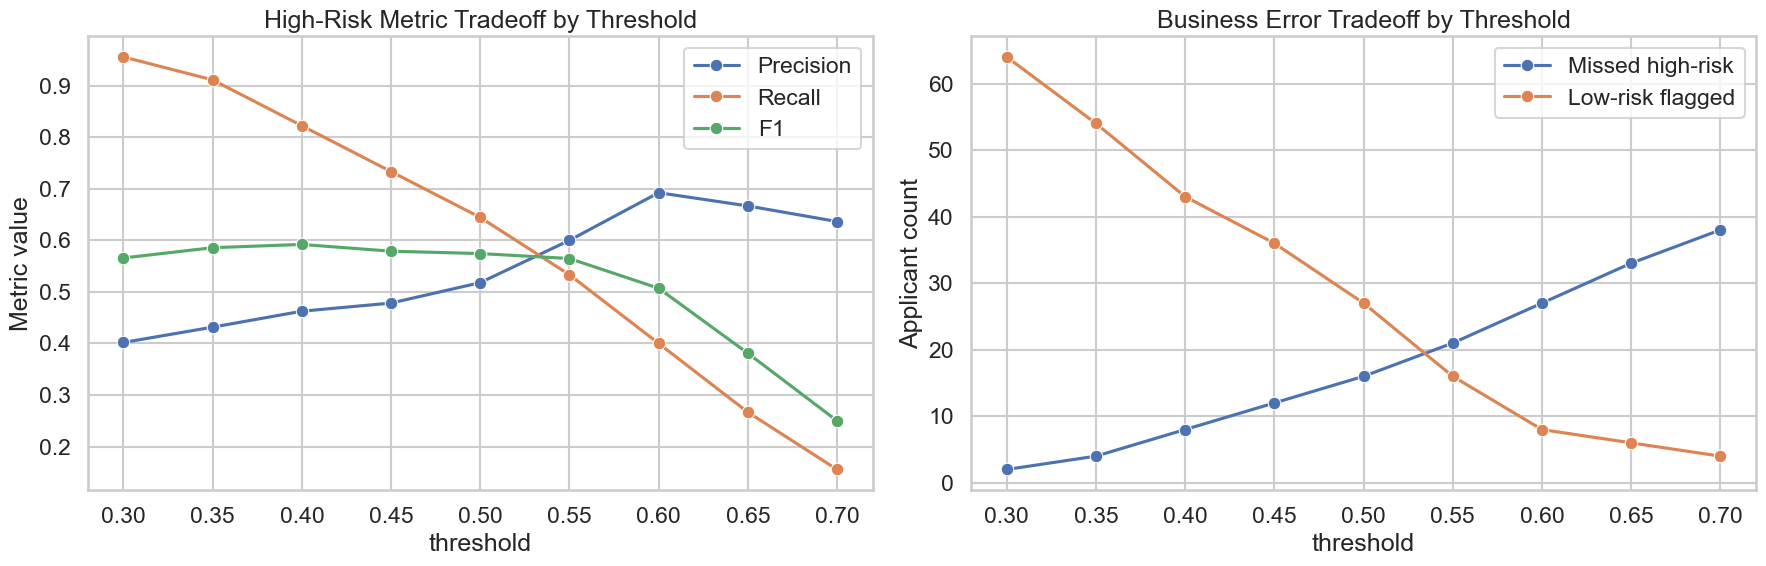

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=threshold_results, x="threshold", y="precision_high_risk", marker="o", label="Precision", ax=axes[0])
sns.lineplot(data=threshold_results, x="threshold", y="recall_high_risk", marker="o", label="Recall", ax=axes[0])
sns.lineplot(data=threshold_results, x="threshold", y="f1_high_risk", marker="o", label="F1", ax=axes[0])
axes[0].set_title("High-Risk Metric Tradeoff by Threshold")
axes[0].set_ylabel("Metric value")

sns.lineplot(data=threshold_results, x="threshold", y="false_negative_high_risk_missed", marker="o", label="Missed high-risk", ax=axes[1])
sns.lineplot(data=threshold_results, x="threshold", y="false_positive_low_risk_flagged", marker="o", label="Low-risk flagged", ax=axes[1])
axes[1].set_title("Business Error Tradeoff by Threshold")
axes[1].set_ylabel("Applicant count")

plt.tight_layout()
plt.show()

## 7. Define Approve, Review, and Reject Bands

Instead of forcing every applicant into approve/reject, create a middle review band for uncertain cases.

In [7]:
approve_threshold = 0.40
reject_threshold = 0.65

def assign_credit_decision(probability: float) -> str:
    if probability < approve_threshold:
        return "approve"
    if probability < reject_threshold:
        return "manual_review"
    return "reject"

valid_scores["decision"] = valid_scores["predicted_high_risk_probability"].apply(assign_credit_decision)

decision_summary = (
    valid_scores.groupby("decision")
    .agg(
        applicants=("actual_high_risk", "size"),
        actual_high_risk_count=("actual_high_risk", "sum"),
        actual_high_risk_rate=("actual_high_risk", "mean"),
        avg_predicted_high_risk_probability=("predicted_high_risk_probability", "mean"),
    )
    .reset_index()
)

decision_summary["actual_high_risk_rate"] = decision_summary["actual_high_risk_rate"].round(4)
decision_summary["avg_predicted_high_risk_probability"] = decision_summary["avg_predicted_high_risk_probability"].round(4)

decision_summary

,decision,applicants,actual_high_risk_count,actual_high_risk_rate,avg_predicted_high_risk_probability
0,approve,70,8,0.1143,0.2621
1,manual_review,62,25,0.4032,0.5222
2,reject,18,12,0.6667,0.7076


## 8. Visualize Decision Bands

Show how applicants are distributed across approve, review, and reject decisions.

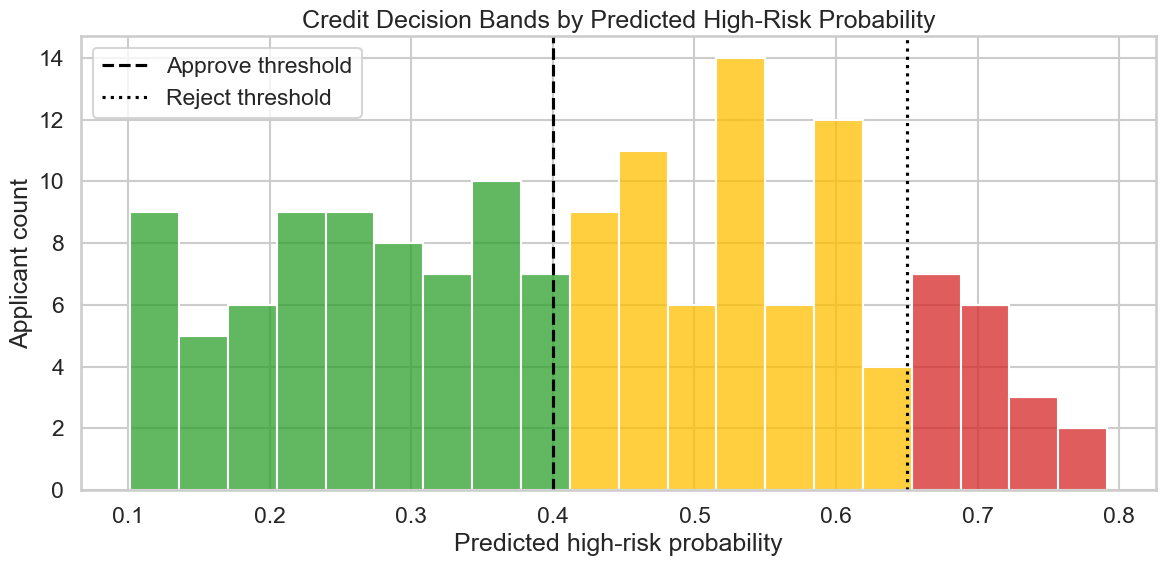

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=valid_scores,
    x="predicted_high_risk_probability",
    hue="decision",
    multiple="stack",
    bins=20,
    palette={"approve": "#2ca02c", "manual_review": "#ffbf00", "reject": "#d62728"},
)
plt.axvline(approve_threshold, color="black", linestyle="--", label="Approve threshold")
plt.axvline(reject_threshold, color="black", linestyle=":", label="Reject threshold")
plt.title("Credit Decision Bands by Predicted High-Risk Probability")
plt.xlabel("Predicted high-risk probability")
plt.ylabel("Applicant count")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Save Decisioning Artifacts


In [9]:
threshold_results_path = tables_dir / "threshold_analysis_validation.csv"
decision_summary_path = tables_dir / "decision_band_summary_validation.csv"
scored_validation_path = tables_dir / "scored_validation_decisions.csv"
decisioning_summary_path = profiles_dir / "business_decisioning_summary.json"

threshold_results.to_csv(threshold_results_path, index=False)
decision_summary.to_csv(decision_summary_path, index=False)
valid_scores.to_csv(scored_validation_path, index=True)

decisioning_summary = {
    "champion_model": "random_forest",
    "approve_threshold": approve_threshold,
    "reject_threshold": reject_threshold,
    "decision_policy": "approve below approve_threshold, manual_review between thresholds, reject at or above reject_threshold",
    "threshold_results_path": str(threshold_results_path.relative_to(project_root)),
    "decision_summary_path": str(decision_summary_path.relative_to(project_root)),
    "scored_validation_path": str(scored_validation_path.relative_to(project_root)),
}

with decisioning_summary_path.open("w") as f:
    json.dump(decisioning_summary, f, indent=2)

threshold_results_path, decision_summary_path, scored_validation_path, decisioning_summary_path

(PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/threshold_analysis_validation.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/decision_band_summary_validation.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/scored_validation_decisions.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/profiles/business_decisioning_summary.json'))

## 10. Business Decisioning Summary

In this stage, I moved the project from model prediction into business decisioning. Instead of treating the model score as the final answer, I used the predicted high-risk probability to design a practical lending workflow.

I compared different classification thresholds to understand the tradeoff between catching high-risk applicants and incorrectly flagging low-risk applicants. This is important in credit risk because the cost of a missed high-risk applicant is different from the cost of sending a low-risk applicant to review.

Based on this, I created a three-band decision policy: applicants with lower predicted risk can be approved, applicants in the middle range can be sent for manual review, and applicants with higher predicted risk can be rejected or reviewed under stricter lending rules.

This approach makes the model more useful for stakeholders because it connects machine learning output to clear business actions, while still allowing human review for uncertain cases.
